# Surface renewal on one day of real data — WES almond orchard, 24 June 2023

This notebook runs both `srflux` detectors end to end on a single day from an almond
orchard eddy-covariance site, and calibrates them against the tower.

**What is in `examples/data/`**

| file | contents |
|---|---|
| `wes_2023-06-24_1hz.csv.gz` | 1 Hz **FWT** (fine-wire thermocouple, air), **IRT** (radiometer target = canopy skin) and **SBT** (the radiometer's own housing thermistor), 86,400 samples |
| `wes_2023-06-24_flux30.csv` | 30-min **NETRAD**, **G**, **H**, **LE** from the tower (48 blocks) |

Nothing else is needed: the two temperature series are the surface-renewal input, and the
four flux terms are the reference and the energy balance.

The two ramp scalars are a deliberate contrast. FWT sits in the air and sees the sharp
microfronts directly; IRT looks at the canopy skin, whose ramps are smoother, smaller and
harder to detect — which is exactly where surface renewal is most useful, because a
radiometer is cheap and needs no sonic.

The third channel, **SBT**, is not a ramp scalar at all. It is the thermistor inside the
radiometer housing, which equilibrates with the *air* rather than the canopy, so the
difference `dT = IRT − SBT ≈ Ts − Ta` is available from the single instrument. Section 6
uses it for the flux direction and the stability class, which is otherwise the one thing
surface renewal cannot get from a radiometer alone.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from srflux import (HaarDetector, VanAttaDetector, prepare_block, ramp_flux,
                    calibrate_alpha, fit_and_score, sensible_heat,
                    latent_heat_residual, daily_et, sign_from_skewness,
                    sign_from_gradient, fit_gradient_offset, stability_from_gradient,
                    surface_air_difference)
from srflux.preprocess import increment_skewness

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

FS = 1.0            # Hz, the raw sampling rate
BLOCK_S = 1800.0    # 30-min averaging period
Z_AIR = 7.5         # m, sonic/fine-wire measurement height
Z_CANOPY = 3.5      # m, canopy height -- the right length scale for a SKIN temperature

hi = pd.read_csv("data/wes_2023-06-24_1hz.csv.gz", parse_dates=["TIMESTAMP"])
fx = pd.read_csv("data/wes_2023-06-24_flux30.csv", parse_dates=["TIMESTAMP"])
hi = hi.set_index("TIMESTAMP")
fx = fx.set_index("TIMESTAMP")

print(hi.describe().round(2).to_string())
fx.head()

            FWT       IRT       SBT
count  86400.00  86400.00  86400.00
mean      23.85     20.83     19.33
std        9.37      8.46      6.39
min        9.77      9.90     10.42
25%       14.97     13.31     13.15
50%       21.59     18.37     18.21
75%       32.81     29.58     26.45
max       38.98     35.16     28.05


,NETRAD,G,H,LE
TIMESTAMP,,,,
2023-06-24 00:00:00,-81.14,43.89,-4.47,-0.20
2023-06-24 00:30:00,-74.48,-16.11,-8.52,-0.26
2023-06-24 01:00:00,-80.23,-18.91,-3.39,-0.78
2023-06-24 01:30:00,-77.99,-20.82,-3.65,-0.11
2023-06-24 02:00:00,-70.91,-20.93,-1.20,-0.15


## 1. The day at a glance

Top: the two raw 1 Hz series. The fine wire tracks air temperature and is visibly noisier;
the canopy skin runs *below* air through the middle of the day, which is what a transpiring
orchard should do — evaporative cooling holds the leaves below the air around them.

Bottom: the surface energy balance. This is an irrigated orchard in June, so most of the
available energy goes into LE, and H is the smaller term. That matters later: an error in
the surface-renewal H is diluted when ET is computed as a residual.

daytime Bowen ratio  H/LE = 0.73
energy-balance closure (H+LE)/(Rn-G) = 1.00


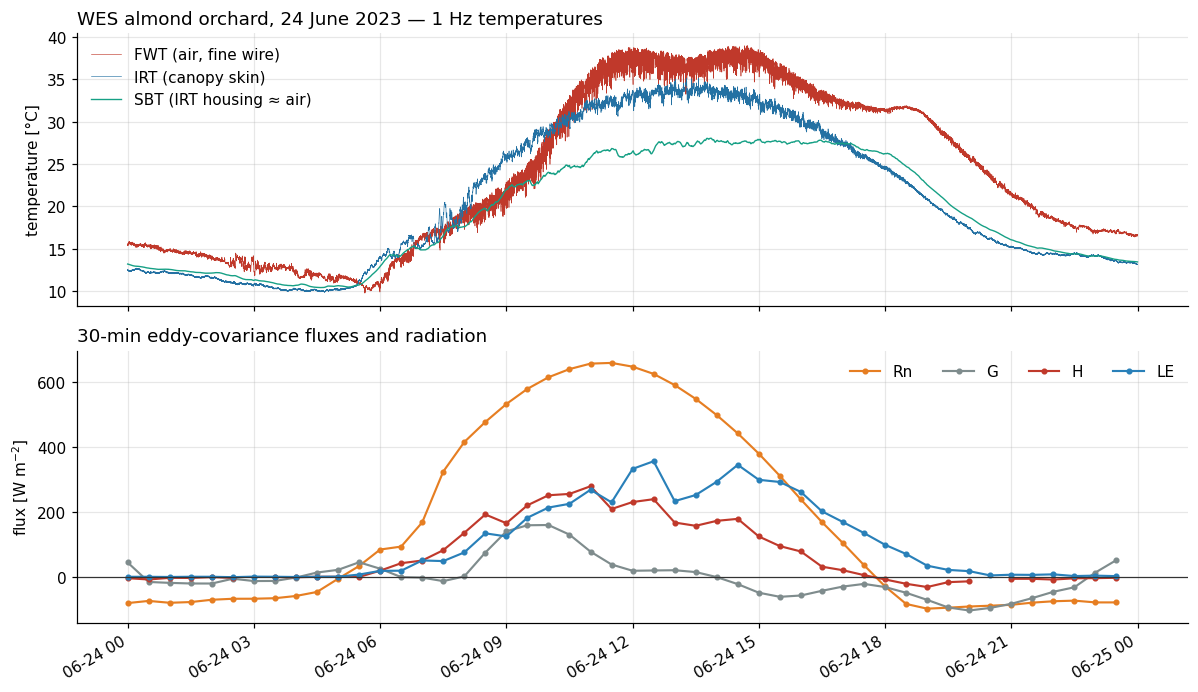

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True,
                               gridspec_kw=dict(height_ratios=[1, 1]))

ax1.plot(hi.index, hi.FWT, lw=0.4, color="#c0392b", label="FWT (air, fine wire)")
ax1.plot(hi.index, hi.IRT, lw=0.4, color="#2471a3", label="IRT (canopy skin)")
ax1.plot(hi.index, hi.SBT, lw=0.9, color="#16a085", label="SBT (IRT housing ≈ air)")
ax1.set_ylabel("temperature [°C]")
ax1.legend(loc="upper left", frameon=False)
ax1.set_title("WES almond orchard, 24 June 2023 — 1 Hz temperatures", loc="left")

for col, clr, lab in [("NETRAD", "#e67e22", "Rn"), ("G", "#7f8c8d", "G"),
                      ("H", "#c0392b", "H"), ("LE", "#2980b9", "LE")]:
    ax2.plot(fx.index, fx[col], "-o", ms=3, lw=1.4, color=clr, label=lab)
ax2.axhline(0, color="#333", lw=0.8)
ax2.set_ylabel("flux [W m$^{-2}$]")
ax2.legend(ncol=4, frameon=False)
ax2.set_title("30-min eddy-covariance fluxes and radiation", loc="left")
fig.autofmt_xdate()
plt.tight_layout()

closure = (fx.H + fx.LE).sum() / (fx.NETRAD - fx.G).sum()
print(f"daytime Bowen ratio  H/LE = {fx.H[fx.NETRAD > 50].sum() / fx.LE[fx.NETRAD > 50].sum():.2f}")
print(f"energy-balance closure (H+LE)/(Rn-G) = {closure:.2f}")

## 2. What a ramp actually looks like

One 30-min block at midday, for both scalars. The top panels show the raw series with its
300 s moving mean; the bottom panels show the detrended signal and the Haar coefficients,
with the detected microfronts marked.

Detection runs on the whole 30-min block; the plot shows the first few minutes so the
individual ramps stay legible. Note the difference in vertical scale — the air ramps are
several times larger than the skin ramps — and look at the asymmetry of each ramp, which
is what section 6 turns out to depend on.

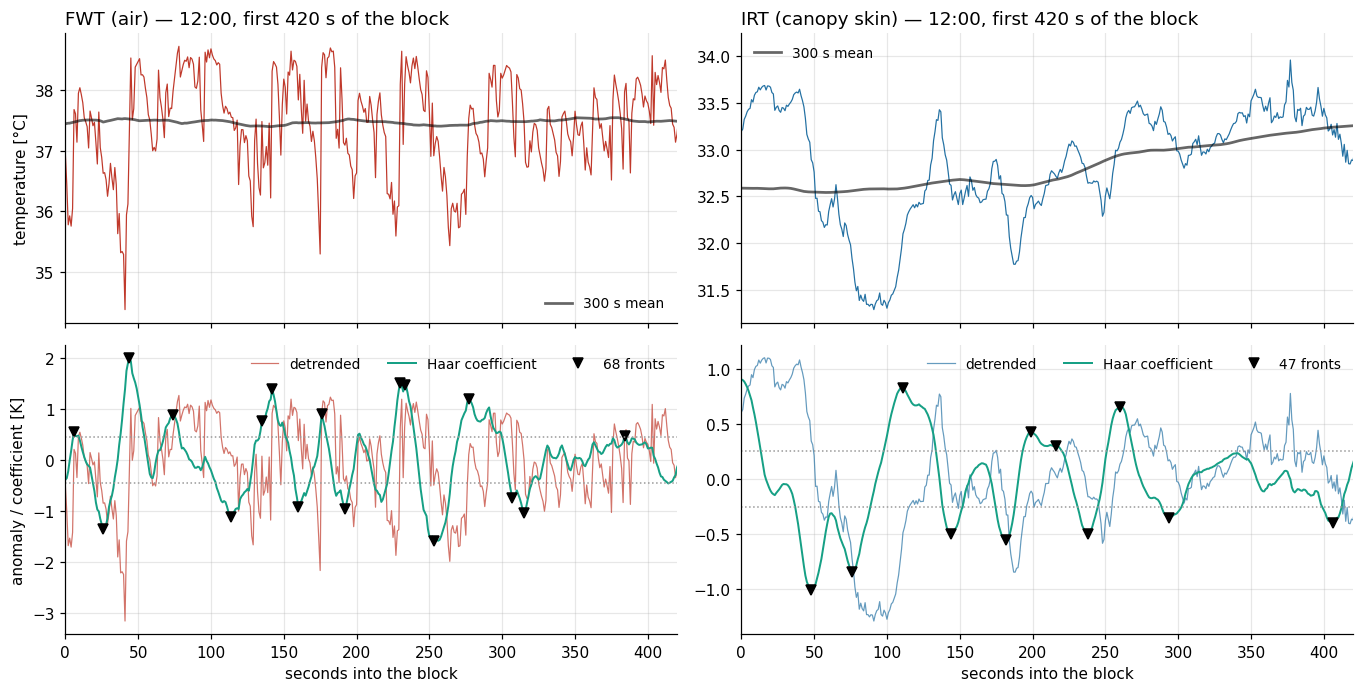

In [3]:
from srflux.preprocess import moving_average

t0 = pd.Timestamp("2023-06-24 12:00:00")
ZOOM_S = 420          # plot this many seconds so individual ramps stay legible
seg = hi.loc[t0:t0 + pd.Timedelta(seconds=BLOCK_S - 1)]
det = HaarDetector(fs=FS)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 6.4), sharex=True)
for j, (col, clr, lab) in enumerate([("FWT", "#c0392b", "FWT (air)"),
                                     ("IRT", "#2471a3", "IRT (canopy skin)")]):
    v = prepare_block(seg[col].to_numpy(), fs=FS).values
    t = np.arange(len(v))
    coef = det.coefficients(v)
    res = det.detect(v)
    idx = res.extra["front_index"]

    axes[0, j].plot(t, v, lw=0.8, color=clr)
    axes[0, j].plot(t, moving_average(v, 300, FS), lw=1.8, color="k", alpha=0.6,
                    label="300 s mean")
    axes[0, j].set_title(f"{lab} — {t0:%H:%M}, first {ZOOM_S} s of the block", loc="left")
    axes[0, j].legend(frameon=False, fontsize=9)

    axes[1, j].plot(t, v - moving_average(v, 300, FS), lw=0.8, color=clr, alpha=0.7,
                    label="detrended")
    axes[1, j].plot(t, coef, lw=1.3, color="#16a085", label="Haar coefficient")
    axes[1, j].plot(idx, coef[idx], "v", ms=6, color="#000000",
                    label=f"{res.count} fronts")
    axes[1, j].axhline(res.extra["threshold"], color="#999", ls=":", lw=1)
    axes[1, j].axhline(-res.extra["threshold"], color="#999", ls=":", lw=1)
    axes[1, j].set_xlabel("seconds into the block")
    axes[1, j].set_xlim(0, ZOOM_S)          # detection uses the whole block; we plot a window
    axes[1, j].legend(frameon=False, fontsize=9, ncol=3)

axes[0, 0].set_ylabel("temperature [°C]")
axes[1, 0].set_ylabel("anomaly / coefficient [K]")
plt.tight_layout()

## 3. Run both detectors on every block

`HaarDetector` (SR-WL) counts fronts and reports their median amplitude; `VanAttaDetector`
(SR-VA) solves the structure-function cubic and reports an amplitude and a ramp period.

Each is turned into an uncalibrated flux with the appropriate length scale — the
measurement height for the air series, the canopy height for the skin series, since the
renewed volume against a canopy skin temperature is the canopy layer.

In [4]:
wl, va = HaarDetector(fs=FS), VanAttaDetector(fs=FS, lag="chen")
Z = {"FWT": Z_AIR, "IRT": Z_CANOPY}

rows = []
for t, g in hi.groupby(pd.Grouper(freq="30min")):
    row = {"TIMESTAMP": t}
    for col in ("FWT", "IRT"):
        qc = prepare_block(g[col].to_numpy(), fs=FS)
        if not qc.ok:
            continue
        rw, rv = wl.detect(qc.values), va.detect(qc.values)
        row[f"{col}_sign"] = sign_from_skewness(qc.values, fs=FS)
        row[f"{col}_skew"] = increment_skewness(qc.values, fs=FS)
        if rw.valid:
            row[f"WL_{col}_N"] = rw.count
            row[f"WL_{col}_A"] = rw.amplitude
            row[f"WL_{col}_F"] = ramp_flux(rw.amplitude, count=rw.count, z=Z[col],
                                           block_s=BLOCK_S)
        if rv.valid:
            row[f"VA_{col}_A"] = rv.amplitude
            row[f"VA_{col}_tau"] = rv.period
            row[f"VA_{col}_lag"] = rv.extra["lag_s"]
            row[f"VA_{col}_F"] = ramp_flux(rv.amplitude, period=rv.period, z=Z[col])
    rows.append(row)

sr = pd.DataFrame(rows).set_index("TIMESTAMP")
d = fx.join(sr)
d["daytime"] = d.NETRAD > 50
day_all = d[d.daytime]

print("median ramp statistics over the day")
print(pd.DataFrame({
    "WL count": [d.WL_FWT_N.median(), d.WL_IRT_N.median()],
    "WL amplitude [K]": [d.WL_FWT_A.median(), d.WL_IRT_A.median()],
    "VA amplitude [K]": [d.VA_FWT_A.median(), d.VA_IRT_A.median()],
    "VA period [s]": [d.VA_FWT_tau.median(), d.VA_IRT_tau.median()],
    "VA Chen lag [s]": [d.VA_FWT_lag.median(), d.VA_IRT_lag.median()],
}, index=["FWT (air)", "IRT (skin)"]).round(2).to_string())

median ramp statistics over the day
            WL count  WL amplitude [K]  VA amplitude [K]  VA period [s]  VA Chen lag [s]
FWT (air)       61.5              0.21              0.56          18.34              2.0
IRT (skin)      60.0              0.12              0.28         107.95             83.0


The Chen lag is the number to look at. It adapts to the scalar: a couple of seconds on the
fine wire, tens of seconds on the skin temperature. A fixed 1 s lag — the textbook choice
for a sonic — would have collapsed on the IRT series.

## 4. Uncalibrated flux against the tower

Before any calibration, the shape is already right: the surface-renewal quantity rises and
falls with H through the day. Calibration is a single multiplicative constant.

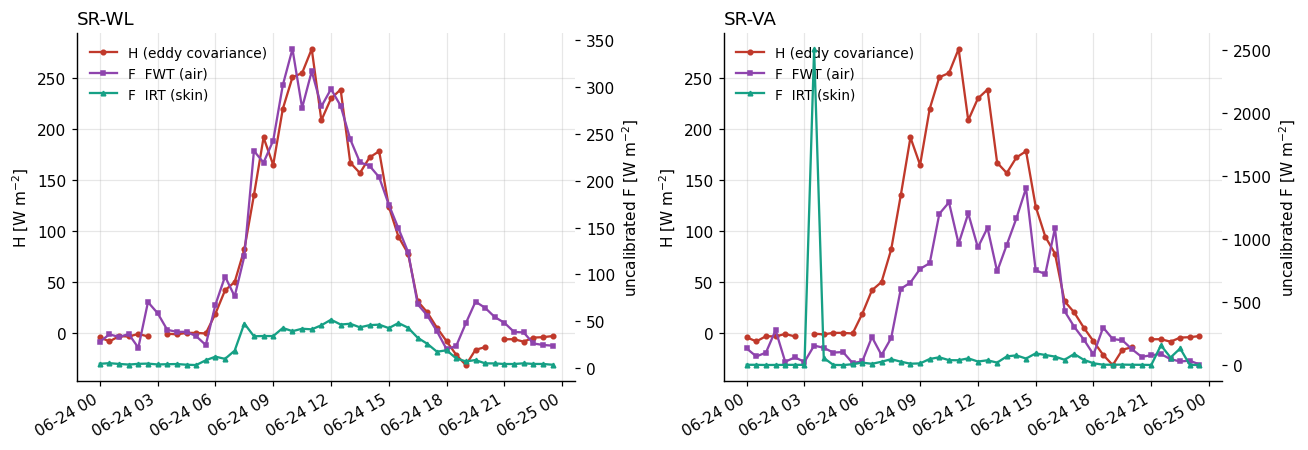

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
for ax, meth in zip(axes, ["WL", "VA"]):
    ax2 = ax.twinx()
    ax.plot(d.index, d.H, "-o", ms=3, color="#c0392b", label="H (eddy covariance)")
    ax2.plot(d.index, d[f"{meth}_FWT_F"], "-s", ms=3, color="#8e44ad",
             label="F  FWT (air)")
    ax2.plot(d.index, d[f"{meth}_IRT_F"], "-^", ms=3, color="#16a085",
             label="F  IRT (skin)")
    ax.set_ylabel("H [W m$^{-2}$]")
    ax2.set_ylabel("uncalibrated F [W m$^{-2}$]")
    ax2.grid(False)
    ax.set_title(f"SR-{meth}", loc="left")
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, frameon=False, fontsize=9, loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()

## 5. Calibrate α and regress against H

α is fitted **through the origin** on convective daytime blocks only (Rn > 50 W m⁻² and
H > 0), so the ramp direction never enters the calibration. With a single day there are
only ~20 usable blocks, so treat these α values as illustrative — the transferability study
behind this package needed 10–21 days spread over the record before α settled to ±10 %.

,method,scalar,z [m],alpha,alpha*z [m],r,RMSE,n
0,SR-WL,FWT,7.5,0.76,5.70,0.97,22.75,23
1,SR-WL,IRT,3.5,3.92,13.71,0.63,62.79,23
2,SR-VA,FWT,7.5,0.19,1.39,0.78,51.30,23
3,SR-VA,IRT,3.5,2.43,8.50,-0.07,108.47,23


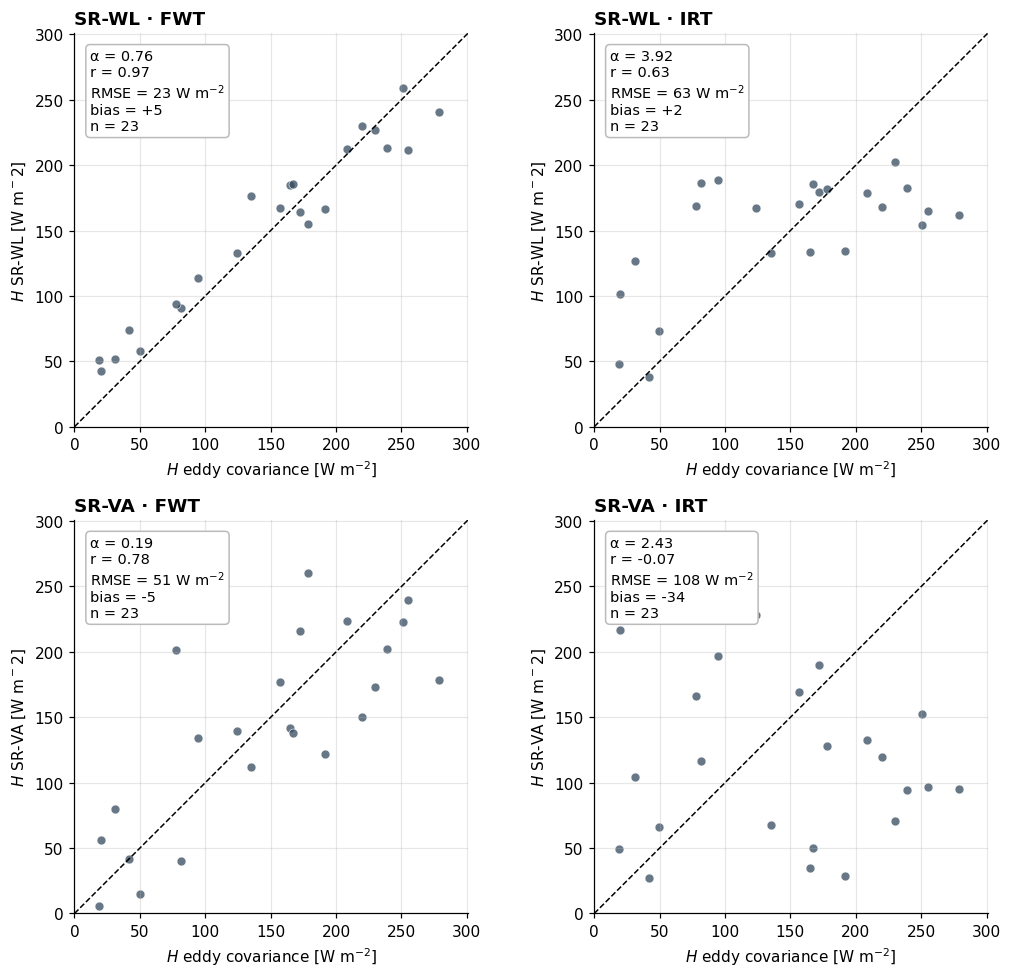

In [6]:
combos = [("WL", "FWT"), ("WL", "IRT"), ("VA", "FWT"), ("VA", "IRT")]
cal = d[d.daytime & (d.H > 0)]

fig, axes = plt.subplots(2, 2, figsize=(9.6, 9.0))
fits = {}
for ax, (meth, col) in zip(axes.ravel(), combos):
    F, H = cal[f"{meth}_{col}_F"].to_numpy(), cal.H.to_numpy()
    m = np.isfinite(F) & np.isfinite(H)
    fit = fit_and_score(F[m], H[m])
    fits[(meth, col)] = fit
    est = fit.alpha * F[m]

    lim = [0, max(est.max(), H[m].max()) * 1.08]
    ax.scatter(H[m], est, s=34, color="#34495e", alpha=0.75, edgecolors="white", lw=0.5)
    ax.plot(lim, lim, "k--", lw=1)
    ax.set(xlim=lim, ylim=lim, aspect="equal")
    ax.set_xlabel("$H$ eddy covariance [W m$^{-2}$]")
    ax.set_ylabel(f"$H$ SR-{meth} [W m$^{-2}$]")
    ax.set_title(f"SR-{meth} · {col}", loc="left", fontweight="bold")
    ax.text(0.04, 0.96, f"α = {fit.alpha:.2f}\nr = {fit.r:.2f}\nRMSE = {fit.rmse:.0f} W m$^{{-2}}$\n"
                        f"bias = {fit.mbe:+.0f}\nn = {fit.n}",
            transform=ax.transAxes, va="top", fontsize=9.5,
            bbox=dict(boxstyle="round", fc="white", ec="#bbb"))
plt.tight_layout()

pd.DataFrame([{"method": f"SR-{m}", "scalar": c, "z [m]": Z[c], "alpha": f.alpha,
               "alpha*z [m]": f.alpha * Z[c], "r": f.r, "RMSE": f.rmse, "n": f.n}
              for (m, c), f in fits.items()]).round(2)

Two things to read off this table rather than the α column alone:

- **α and z are not separately identifiable.** Only their product enters the flux, so `α·z`
  is the quantity the data constrain. Comparing raw α between the air and skin channels
  compares two different height conventions, not two different physics.
- **r is scale-invariant.** It does not depend on α at all, so it — not RMSE — is the honest
  measure of which detector and which scalar tracks the flux better.

## 6. Flux direction and stability from the radiometer alone (Ta from the sensor body)

The ramp amplitude says how big the exchange is, not which way it goes. Three candidates,
none of which needs a sonic:

1. `sign_from_skewness` on the **air** ramp — a warm ramp rises gradually and collapses
   sharply, so the increment skewness is negative;
2. the same on the **skin** ramp;
3. `sign_from_gradient` — the **surface-air temperature difference** `dT = IRT − SBT`, taken
   from the two channels of the one radiometer. The housing thermistor tracks air rather
   than canopy, so dT is a direct thermodynamic statement: surface warmer than air means
   heat goes up. No time-domain statistics at all.

The first thing to check is whether the housing really behaves like an air sensor here.

In [7]:
b = hi.resample("30min").mean()
d = d.join(b[["SBT"]].rename(columns={"SBT": "SBT_mean"}))
d = d.join(hi.IRT.resample("30min").mean().rename("IRT_mean"))
d["dT"] = surface_air_difference(d.IRT_mean, d.SBT_mean)
day_all = d[d.daytime]

print(f"SBT vs FWT over the day:  r = {b.SBT.corr(b.FWT):.3f}, "
      f"mean SBT − FWT = {(b.SBT - b.FWT).mean():+.2f} K")
print(f"midday (11–15 h) FWT {b.FWT.between_time('11:00','15:00').mean():.1f} °C, "
      f"SBT {b.SBT.between_time('11:00','15:00').mean():.1f} °C, "
      f"IRT {b.IRT.between_time('11:00','15:00').mean():.1f} °C")

SBT vs FWT over the day:  r = 0.972, mean SBT − FWT = -4.52 K
midday (11–15 h) FWT 37.0 °C, SBT 27.2 °C, IRT 32.9 °C


The housing tracks the fine wire almost perfectly in *shape* (r = 0.97) but sits several
kelvin below it in *level*. That gap is the crux of this section: which of the two is the
air temperature the canopy actually exchanges with?

The answer is decided empirically, by which one gets the flux direction right.

In [8]:
sources = {
    "skewness · FWT (air ramp)":  day_all.FWT_sign,
    "skewness · IRT (skin ramp)": day_all.IRT_sign,
    "gradient · IRT − SBT":       sign_from_gradient(day_all.IRT_mean, day_all.SBT_mean),
    "gradient · IRT − FWT":       sign_from_gradient(day_all.IRT_mean,
                                                     b.FWT.reindex(day_all.index)),
}
truth = np.sign(day_all.H)
pd.DataFrame([{"sign source": k,
               "agrees with sign(H_EC)": f"{100 * np.mean(np.asarray(v) == truth):.0f} %",
               "says 'upward' in": f"{int(np.nansum(np.asarray(v) > 0))}/{len(day_all)} blocks"}
              for k, v in sources.items()])

,sign source,agrees with sign(H_EC),says 'upward' in
0,skewness · FWT (air ramp),0 %,0/23 blocks
1,skewness · IRT (skin ramp),87 %,20/23 blocks
2,gradient · IRT − SBT,96 %,22/23 blocks
3,gradient · IRT − FWT,30 %,7/23 blocks


**The body-referenced gradient wins outright**, and the fine-wire-referenced one does not.
Using the housing as Ta, the canopy is warmer than the air all day and the direction is
right in essentially every block; using the fine wire as Ta, the canopy looks *colder* than
the air and the direction comes out backwards — the same failure as the ramp skewness in
the previous version of this notebook.

This matches what a three-site test of the same diagnostic found: 80–87 % correct with a
fitted offset, against 61–78 % for the ramp skewness of the same skin temperature, and
93–95 % for air-ramp skewness (which needs a sonic-grade air series). One caveat carried
over from that work: use the housing's **mean temperature**, never its ramps — the body
ramp amplitude sits at the detector noise floor (0.014–0.021 K against 0.15–0.35 K on the
target channel), and body-ramp skewness scored barely above chance.

The flip threshold is not exactly zero, because the housing is shaded or radiatively loaded
depending on the mount. `fit_gradient_offset` calibrates it — fit on one subset of days,
score on another. With a single day there is nothing to hold out, so the number below is
in-sample and shown only to demonstrate the call.

offset 0.0 K  -> 96 % correct
offset -0.12 K -> 96 % correct   (in-sample)


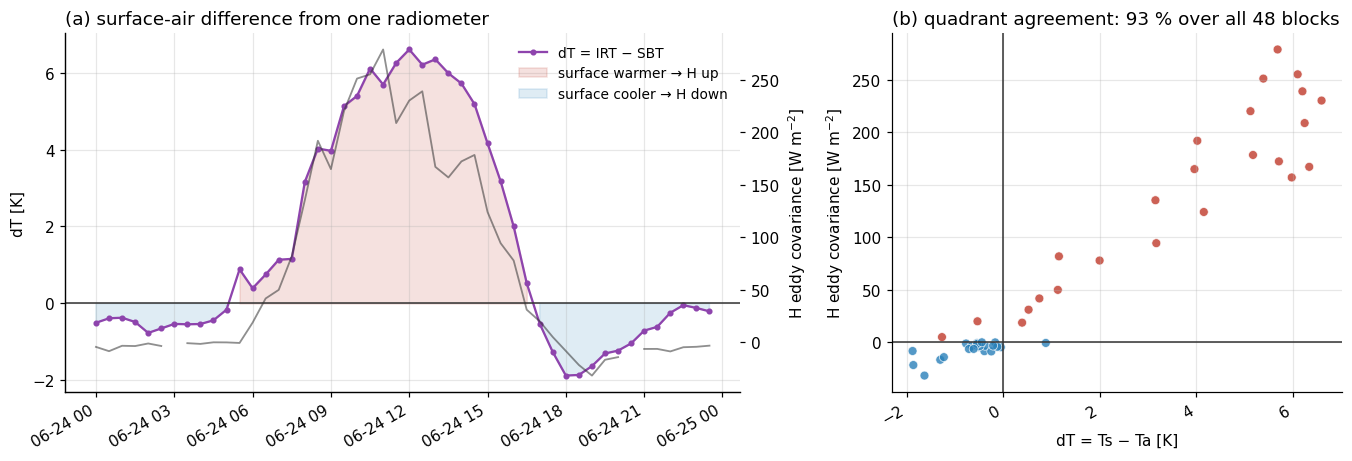

In [9]:
off = fit_gradient_offset(day_all.IRT_mean, day_all.SBT_mean, np.sign(day_all.H))
acc0 = np.mean(sign_from_gradient(day_all.IRT_mean, day_all.SBT_mean) == np.sign(day_all.H))
acco = np.mean(sign_from_gradient(day_all.IRT_mean, day_all.SBT_mean, off) == np.sign(day_all.H))
print(f"offset 0.0 K  -> {100 * acc0:.0f} % correct")
print(f"offset {off:+.2f} K -> {100 * acco:.0f} % correct   (in-sample)")

sr_sign = sign_from_gradient(d.IRT_mean, d.SBT_mean)
klass = stability_from_gradient(d.IRT_mean, d.SBT_mean, cuts=(-0.5, 0.5))

fig, (axl, axr) = plt.subplots(1, 2, figsize=(12.4, 4.3),
                               gridspec_kw=dict(width_ratios=[1.5, 1]))
axl.plot(d.index, d.dT, "-o", ms=3, color="#8e44ad", label="dT = IRT − SBT")
axl.axhline(0, color="#333", lw=1)
axl.fill_between(d.index, 0, d.dT.where(d.dT > 0), color="#c0392b", alpha=0.15,
                 label="surface warmer → H up")
axl.fill_between(d.index, 0, d.dT.where(d.dT < 0), color="#2980b9", alpha=0.15,
                 label="surface cooler → H down")
axl.set_ylabel("dT [K]")
axl.legend(frameon=False, fontsize=9)
axl.set_title("(a) surface-air difference from one radiometer", loc="left")
ax2 = axl.twinx()
ax2.plot(d.index, d.H, lw=1.2, color="#333333", alpha=0.55)
ax2.set_ylabel("H eddy covariance [W m$^{-2}$]")
ax2.grid(False)

ok = np.isfinite(d.dT) & np.isfinite(d.H)
axr.scatter(d.dT[ok], d.H[ok], s=34, c=np.where(d.H[ok] > 0, "#c0392b", "#2980b9"),
            alpha=0.8, edgecolors="white", lw=0.5)
axr.axhline(0, color="#333", lw=1)
axr.axvline(0, color="#333", lw=1)
axr.set_xlabel("dT = Ts − Ta [K]")
axr.set_ylabel("H eddy covariance [W m$^{-2}$]")
axr.set_title(f"(b) quadrant agreement: {100 * np.mean(np.sign(d.dT[ok]) == np.sign(d.H[ok])):.0f} %"
              " over all 48 blocks", loc="left")
fig.autofmt_xdate()
plt.tight_layout()

Panel (b) is the whole convention in one picture: blocks should fall in the upper-right and
lower-left quadrants. The nocturnal blocks (blue, lower-left) work as well as the convective
ones, which the ramp-shape conventions generally do not — at night the ramps are weak and
their asymmetry is ambiguous, while the temperature difference is still unambiguous.

The rest of the notebook uses this dT sign.

## 7. Close the energy balance and get ET

With H from surface renewal — direction from the dT sign of section 6 — LE follows as the
residual `LE = Rn − G − H`, and daily ET is its time integral. Because α was fitted on these
same blocks, these are in-sample numbers: a demonstration of the chain, not a validation of
it.

,ET [mm]
SR-WL · FWT,4.24
SR-WL · IRT,4.39
SR-VA · FWT,4.44
SR-VA · IRT,5.16
EC residual (Rn−G−H),4.27
EC measured LE,3.39


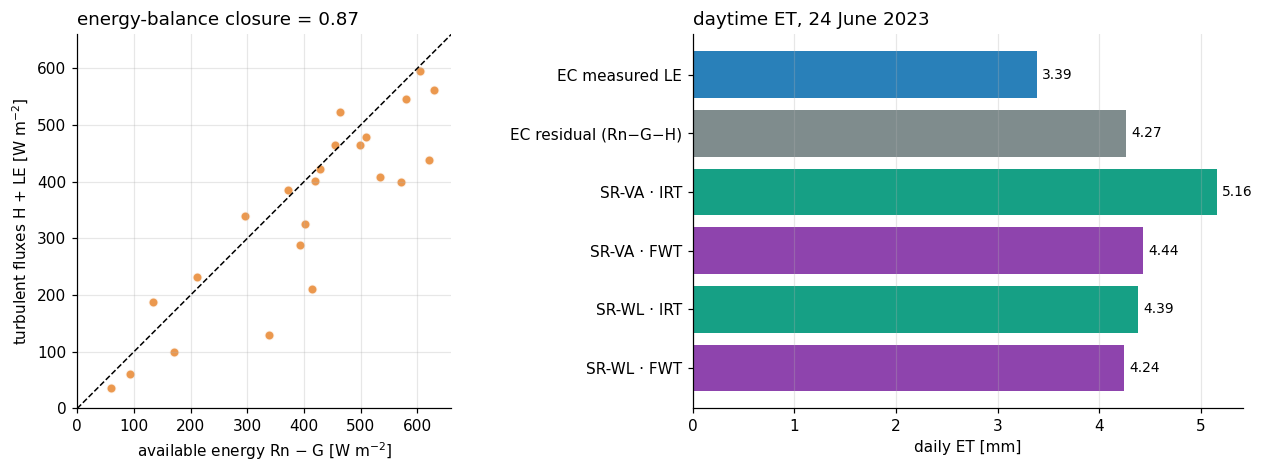

In [10]:
LAMBDA = 2.45e6
day = d[d.daytime].copy()

et = {}
for (meth, col), fit in fits.items():
    H_sr = sensible_heat(day[f"{meth}_{col}_F"].to_numpy(), fit.alpha,
                         sign=sign_from_gradient(day.IRT_mean, day.SBT_mean))
    le = latent_heat_residual(day.NETRAD.to_numpy(), day.G.to_numpy(), H_sr)
    et[f"SR-{meth} · {col}"] = daily_et(le, block_s=BLOCK_S)

et["EC residual (Rn−G−H)"] = daily_et(
    latent_heat_residual(day.NETRAD.to_numpy(), day.G.to_numpy(), day.H.to_numpy()),
    block_s=BLOCK_S)
et["EC measured LE"] = daily_et(day.LE.to_numpy(), block_s=BLOCK_S)

fig, (axa, axb) = plt.subplots(1, 2, figsize=(12, 4.4))

avail = (day.NETRAD - day.G).to_numpy()
turb = (day.H + day.LE).to_numpy()
lim = [0, max(avail.max(), turb.max()) * 1.05]
axa.scatter(avail, turb, s=38, color="#e67e22", alpha=0.8, edgecolors="white")
axa.plot(lim, lim, "k--", lw=1)
sl = np.sum(avail * turb) / np.sum(avail ** 2)
axa.set(xlim=lim, ylim=lim, aspect="equal",
        xlabel="available energy Rn − G [W m$^{-2}$]",
        ylabel="turbulent fluxes H + LE [W m$^{-2}$]")
axa.set_title(f"energy-balance closure = {sl:.2f}", loc="left")

names = list(et)
axb.barh(names, [et[k] for k in names],
         color=["#8e44ad", "#16a085", "#8e44ad", "#16a085", "#7f8c8d", "#2980b9"])
axb.set_xlabel("daily ET [mm]")
axb.set_title("daytime ET, 24 June 2023", loc="left")
for i, k in enumerate(names):
    axb.text(et[k] + 0.05, i, f"{et[k]:.2f}", va="center", fontsize=9)
axb.grid(axis="y", alpha=0)
plt.tight_layout()

pd.Series(et).round(2).to_frame("ET [mm]")

The measured-LE bar sits below the residual bars because this tower, like most, does not
close its energy balance — the residual method assigns the missing energy to LE. That gap
is a property of the site, not of surface renewal, and it is why calibrating against a
closure-corrected H is preferable when one is available.

## Takeaways

1. **SR-WL on the fine wire is the clear winner here** (r = 0.97): a single multiplicative
   constant reproduces the tower's H across the day. SR-WL on the canopy skin is usable
   (r = 0.63) and SR-VA on the fine wire is intermediate (r = 0.78).
2. **SR-VA on the skin temperature fails on this day** (r ≈ 0). Its per-block Chen lag
   ranges from 15 s to over 300 s, and since the flux is A/tau, a noisy period scatters the
   estimate. Over a full record it recovers (the multi-year study behind this package gets
   r ≈ 0.6–0.85 for VA on surface temperature); one day of 23 blocks is not enough to
   average that noise out. Do not read a single day as a verdict on a method.
3. **Take the flux direction from the radiometer's own housing thermistor.** `dT = Ts − Ta`
   with Ta from the sensor body got the sign right in ~96 % of daytime blocks and worked at
   night too, while the ramp-skewness convention on the fine wire got it wrong in every
   daytime block. Use the body's mean temperature, never its ramps.
4. Compare `α·z`, not α, whenever the length-scale convention differs — only the product is
   identifiable from data.
5. One day demonstrates the method and is nowhere near enough to calibrate it: plan on
   10–21 days spread across conditions, not one continuous campaign.